# Convert raw signal into spikes
- Signal preprocessing and spike conversion

In [1]:
import sys
sys.path.insert(0, "../")

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from src.config import PreprocessConfig
from src.offline.data_io import load_signals_and_annotations
from src.offline.dsp import clip_outliers, apply_causal_filters, downsample_all

cfg = PreprocessConfig()

## Load Raw signal and process

In [26]:
recording_path = Path("../data/raw/tr03-0005")
raw_signals, arousals, sleep_stages = load_signals_and_annotations(recording_path, channels=[2,3])

clipped_raw_signals = clip_outliers(raw_signals, clip_threshold=cfg.clip_threshold, win_size=15)
processed_signals = apply_causal_filters(clipped_raw_signals, cfg)

processed_signals, arousals, sleep_stages = downsample_all(
    cfg.downsample_factor, 
    processed_signals, arousals, sleep_stages
)

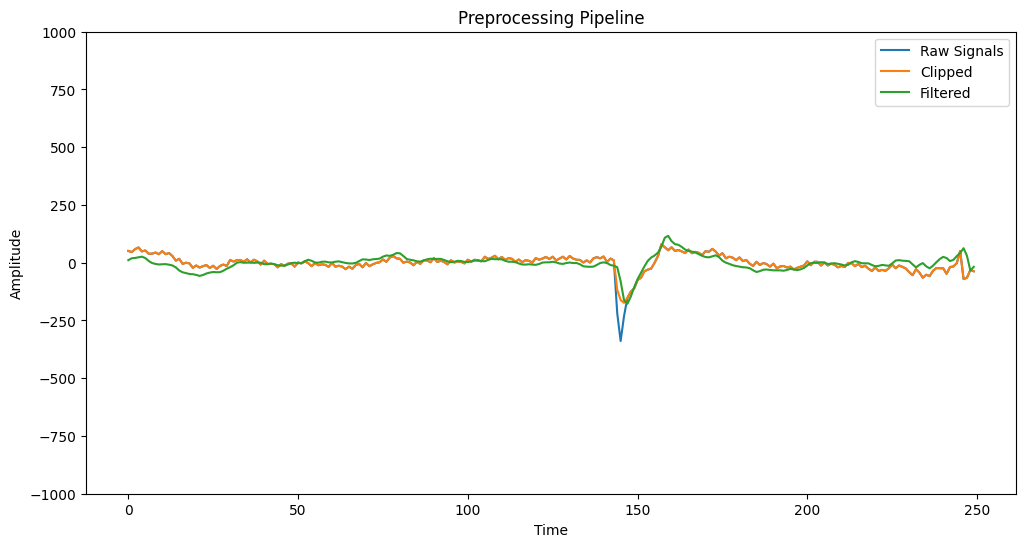

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(raw_signals[:, ::2][0, 685*cfg.hop_length:690*cfg.hop_length], label="Raw Signals")
plt.plot(clipped_raw_signals[:, ::2][0, 685*cfg.hop_length:690*cfg.hop_length], label="Clipped")
plt.plot(processed_signals[0, 685*cfg.hop_length:690*cfg.hop_length], label="Filtered")
plt.title("Preprocessing Pipeline")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-1000, 1000)
plt.legend()

Text(0.5, 1.0, 'Processed EEG Signal')

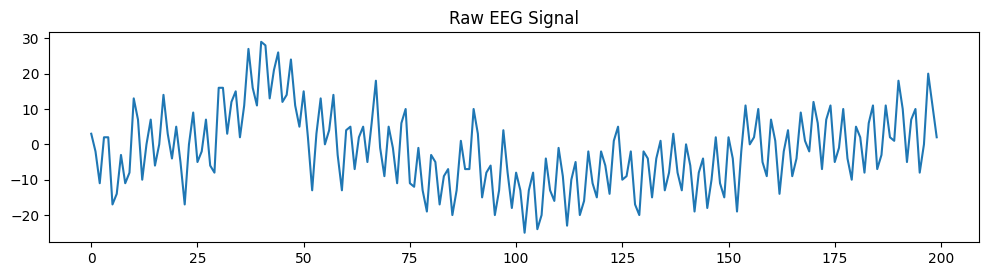

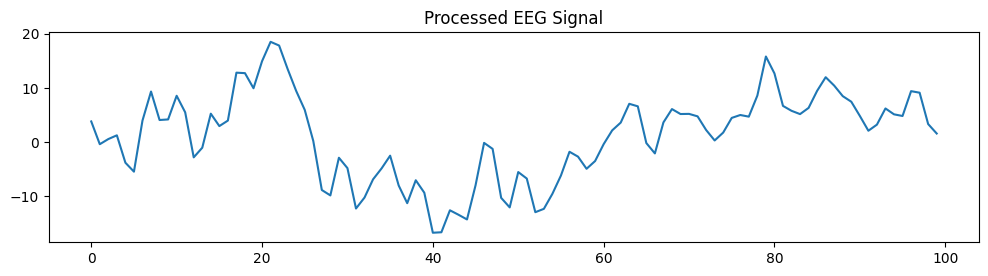

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(raw_signals[0, 24000:24200], label="EEG")
plt.title("Raw EEG Signal")

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(processed_signals[0, 12000:12100], label="EEG")
plt.title("Processed EEG Signal")

## Feature Extraction

In [32]:
from src.offline.dsp import compute_full_recording_bandpower

spectral_timeline = compute_full_recording_bandpower(
    processed_signals, 
    fs=cfg.fs, 
    n_fft=cfg.n_fft,
    hop_length=cfg.hop_length
)

In [33]:
spectral_timeline.shape

(10, 51471)

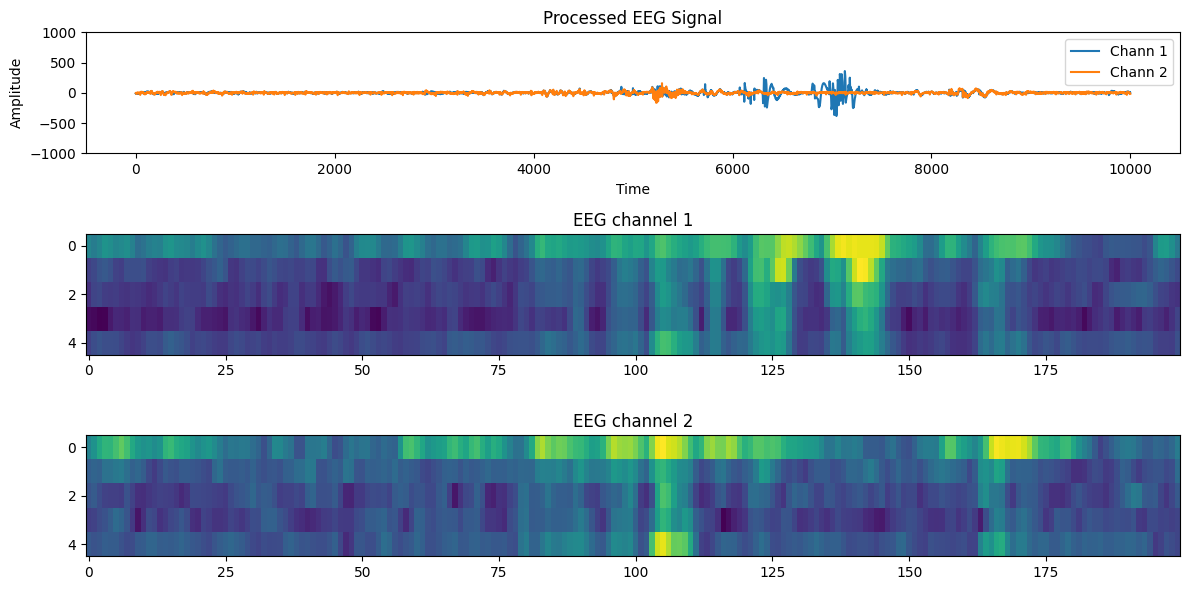

In [34]:
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(processed_signals[0, 200*cfg.hop_length:400*cfg.hop_length], label="Chann 1")
plt.plot(processed_signals[1, 200*cfg.hop_length:400*cfg.hop_length], label="Chann 2")
plt.title("Processed EEG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.ylim(-1000, 1000)
plt.legend()

plt.subplot(3, 1, 2)
plt.imshow(spectral_timeline[:5, 200:400], aspect='auto')
plt.title("EEG channel 1")

plt.subplot(3, 1, 3)
plt.imshow(spectral_timeline[5:10, 200:400], aspect='auto')
plt.title("EEG channel 2")

plt.tight_layout()

## Spike Conversion

In [ ]:
def signal_to_spikes(signal: np.ndarray, threshold: int) -> np.ndarray:
    